# Part 2 — molecule-head prediction metrics (`grid_0000`, plain balanced BCE)

Evaluates the molecule classification head's actual predictive quality on its held-out
test split, for all 5 repetitions of `grid_0000` (`balanced_bce`, no contractive/
contrastive terms — see `../report/methodology.md` §5). Scope for this pass, matching
`part_1`: **`grid_0000` only** — the other six objectives are a later, separate
comparison against this one.

**Why this needs its own careful metrics, not just accuracy**: the head predicts 508
molecule/adduct classes per pixel, and a typical pixel has only a handful of them
present (§2 of the methodology doc: `annotated_fraction=1.0` only guarantees ≥1
positive class per pixel, not per-class balance). A model that predicts **all zeros**
would still score a deceptively high accuracy/precision/hamming-loss on most classes,
simply because "absent" is the overwhelming majority label everywhere. This notebook
makes that trap explicit by computing the same metrics for an actual all-zero baseline
and comparing them side by side against the trained model.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import (
    evaluate_head,
    per_class_metrics,
    probabilities_from_logits,
)
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-27 02:42:00,472 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 02:42:00,475 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-27 02:42:01,394 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 02:42:01,396 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 02:42:01,398 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 02:42:01,399 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 02:42:01,420 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-27 02:42:01,439 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-27 02:42:01,440 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config


In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
MODEL_NAMES = [f"{CAMPAIGN_ID}__grid_0000__rep_0{repetition}" for repetition in range(5)]
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

theme = resolve_theme(None)
theme.apply()


## Environment workaround — entropy-trained `config.json` bakes in scratch paths

Every predictive-campaign model's saved `config.json` records its annotation store at
an **absolute SLURM scratch path**
(`/tmp/<remote-user>/msi-wrapper/predictive-20260824-04/kidney_workspace/datasets/kidney/kidney.sqlite`)
— the compute node's local `/tmp`, already cleaned up (see `part_0`'s notes on
`result.model_path`). Unlike the spectral reader (which resolves relative to the
workspace's own image registry and loaded successfully regardless), the annotation
reader (`MergedAnnotationReader`) trusts this stored absolute path with no fallback and
raises if it is missing.

This recreates that expected path locally as a symlink to the real, already-present
local copy — a pure filesystem workaround (no code changed) so
`wrapper.load_configuration()` can restore the full pipeline (reader, annotation
reader, binner, dataset, model) exactly as saved. Safe to re-run; `ln -sfn` overwrites
the same link idempotently.


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())
print(f"{SCRATCH_WORKSPACE_ROOT} -> {SCRATCH_WORKSPACE_ROOT.resolve()}")


/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace -> /home/max/repositories/MSIAutoEncoderWrapper/data/kidney_workspace


## Load one model + its test split, run inference

`dataset.create_partitions()` replays the exact `predefined` train/validation/test
spectrum-id assignments baked into the saved `config.json` (verified: `len(test) ==
4023`, matching the assignments recorded at training time) — this is the same held-out
population the trainer itself never optimized against, restricted the same way for
every repetition since all `grid_0000` runs share one split seed.


In [4]:
# All 5 repetitions share one image/binner/annotation-store/dataset context — only
# the model weights differ between them. `load_configuration` unconditionally
# re-resolves the raw imzML reader and annotation index on every call (measured
# ~38-40s), even when nothing about the image changed. `models_manager.load_model`
# swaps only the model architecture/weights (its own docstring: "does not require
# loading its original image") and leaves `active_dataset`/context untouched
# (measured ~0.04s) — pay the full context cost exactly once, then use the
# lightweight swap for the remaining 4 repetitions.
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=MODEL_NAMES[0])
shared_test_dataset = wrapper.active_dataset.create_partitions().test


def evaluate_test_split(model_name: str, *, first: bool) -> dict:
    model = (
        wrapper.active_model
        if first
        else wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    )
    model.eval()
    device = next(model.parameters()).device

    logits_batches, target_batches, mask_batches = [], [], []
    loader = DataLoader(shared_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for _, spectra, targets, masks in loader:
            outputs = model(spectra.float().to(device))
            logits_batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
            target_batches.append(targets[TARGET_FIELD].numpy())
            mask_batches.append(masks[TARGET_FIELD].numpy())
    return {
        "logits": np.concatenate(logits_batches, axis=0),
        "targets": np.concatenate(target_batches, axis=0),
        "mask": np.concatenate(mask_batches, axis=0),
        "test_size": len(shared_test_dataset),
    }


results = {
    model_name: evaluate_test_split(model_name, first=(index == 0))
    for index, model_name in enumerate(MODEL_NAMES)
}
{name: result["test_size"] for name, result in results.items()}

2026-08-27 02:42:02,268 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 02:42:02,269 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 02:42:02,271 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 02:42:02,272 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 02:42:02,273 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 02:43:29,531 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 02:43:29,531 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 02:43:29,534 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 02:43:29,540 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


{'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_01': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_02': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_03': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_04': 4023}

## Train vs. validation vs. test — is the model biased toward what it trained on?

Every metric above (and below) is computed on `test` only. Same `evaluate_head`
metrics, computed here on the pixels the model actually trained on (`train`) and the
pixels used for checkpoint selection but never trained on directly (`validation`), for
repetition 0 — matching `part_6`'s convention (all 5 repetitions on `test`, one
repetition additionally on `train`/`validation`) for a direct generalization-gap read
rather than relying on training loss curves alone.


In [5]:
def evaluate_split(model, dataset) -> dict:
    device = next(model.parameters()).device
    logits_batches, target_batches, mask_batches = [], [], []
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for _, spectra, targets, masks in loader:
            outputs = model(spectra.float().to(device))
            logits_batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
            target_batches.append(targets[TARGET_FIELD].numpy())
            mask_batches.append(masks[TARGET_FIELD].numpy())
    return {
        "logits": np.concatenate(logits_batches, axis=0),
        "targets": np.concatenate(target_batches, axis=0),
        "mask": np.concatenate(mask_batches, axis=0),
        "size": len(dataset),
    }


# Re-load rep_0 explicitly rather than trusting wrapper.active_model — the loop above
# left it pointing at whichever repetition was loaded last (rep_4), since
# `models_manager.load_model` updates the wrapper's active model as a side effect.
# `active_dataset`/context are untouched by any of this (same context every repetition),
# so `create_partitions()` here still returns the correct, shared train/validation split.
rep0_model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=MODEL_NAMES[0], strict=True)
rep0_model.eval()
rep0_partitions = wrapper.active_dataset.create_partitions()

gap_results = {
    "train": evaluate_split(rep0_model, rep0_partitions.train),
    "validation": evaluate_split(rep0_model, rep0_partitions.validation),
    "test": results[MODEL_NAMES[0]],
}

gap_rows = []
for split_name, result in gap_results.items():
    metrics = evaluate_head(result["logits"], result["targets"], "multi_label", result["mask"], THRESHOLD)
    gap_rows.append({"split": split_name, "size": result.get("size", result.get("test_size")), **metrics})

gap_frame = pd.DataFrame(gap_rows)
gap_frame[["split", "size", "macro_f1", "average_precision", "hamming_loss"]]


2026-08-27 02:43:33,579 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 02:43:33,580 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-08-27 02:43:33,580 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-08-27 02:43:33,581 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-08-27 02:43:33,583 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-08-27 02:43:33,590 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 02:43:33,591 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 02:43:33,594 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 02:43:33,599 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


,split,size,macro_f1,average_precision,hamming_loss
0,train,33553,0.232623,0.613690,0.327261
1,validation,4488,0.094898,0.203783,0.316444
2,test,4023,0.051750,0.385860,0.323778


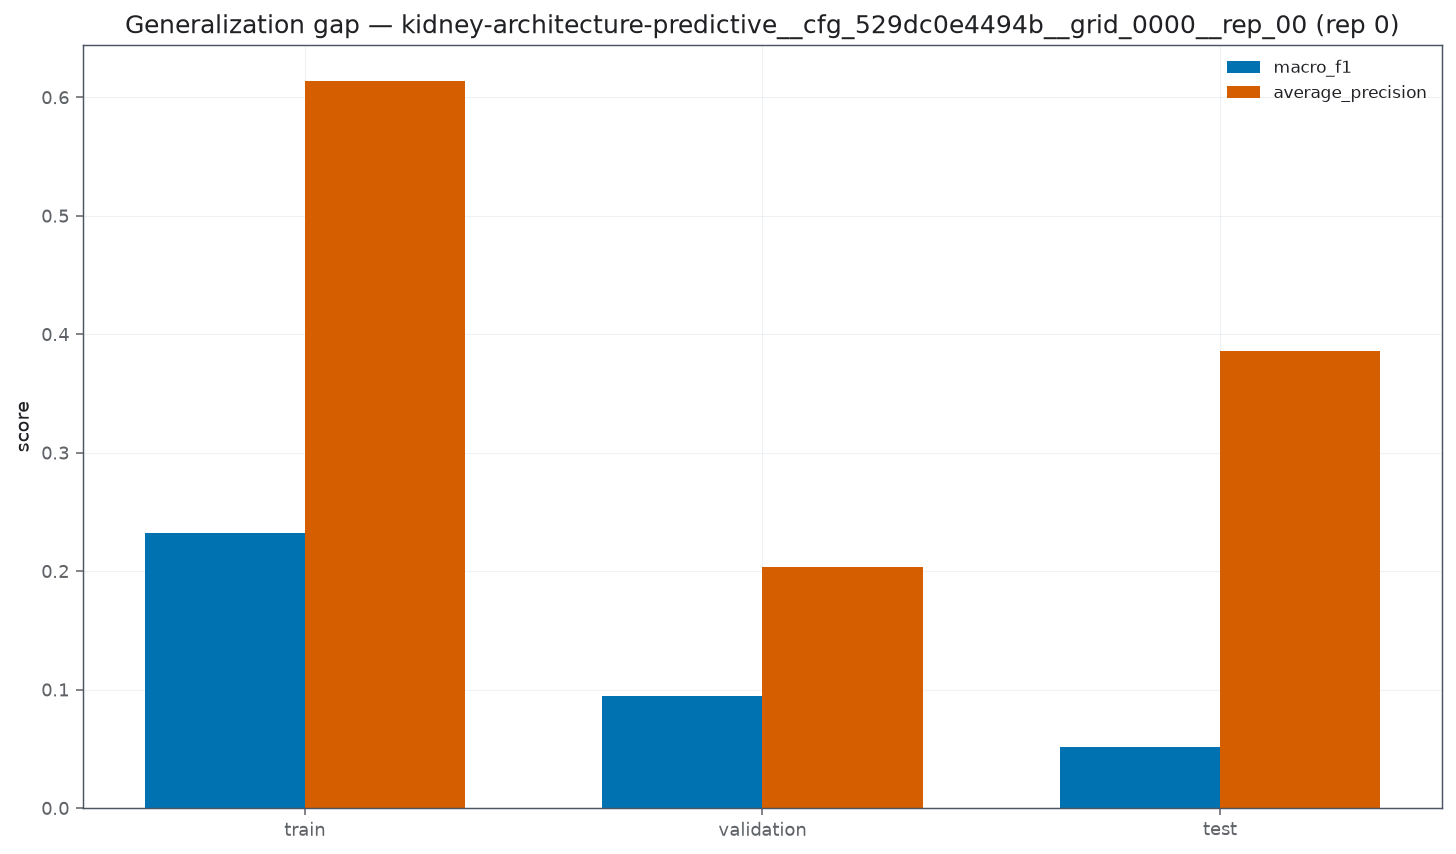

In [6]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
split_order = ["train", "validation", "test"]
metric_names = ["macro_f1", "average_precision"]
x_positions = np.arange(len(split_order))
bar_width = 0.35
for index, metric_name in enumerate(metric_names):
    values = [gap_frame.set_index("split").loc[split_name, metric_name] for split_name in split_order]
    ax.bar(x_positions + index * bar_width, values, width=bar_width, label=metric_name, color=theme.color_for_model(metric_name, index))
ax.set_xticks(x_positions + bar_width / 2)
ax.set_xticklabels(split_order)
ax.set(ylabel="score", title=f"Generalization gap — {MODEL_NAMES[0]} (rep 0)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


**Why `validation` AUPRC (0.204) is *lower* than `test` AUPRC (0.386), despite
`macro_f1` decreasing monotonically train→validation→test as expected**: this is not
evidence the model generalizes worse to validation than to test — it is a split
composition artifact, confirmed directly against the ground-truth annotations
(independent of any model):

| | classes w/ any positive | overlap with `train`'s classes | positives on train-unseen classes |
|---|---|---|---|
| `train` | 204 / 508 | — | — |
| `validation` | 319 / 508 | 68 (21%) | 156,107 / 190,604 (**82%**) |
| `test` | 113 / 508 | 31 (27%) | 83,716 / 117,294 (**71%**) |

`validation` actually has *more* distinct annotated classes present than `train` does,
despite `train` having 7.5x more pixels — and 82% of every positive label in
`validation` belongs to a molecule class the model has **zero** positive training
examples for (some at up to ~2000/4488 ≈ 45% prevalence *within* `validation` alone,
per-class). The model cannot have learned anything about a class it never saw a single
positive example of; scoring it there is closer to measuring zero-shot generalization
to unseen classes than measuring overfitting. `test` has the same problem at a smaller
scale (71% of its positives are on train-unseen classes), which is the more likely
explanation for `test`'s own AUPRC being well below `train`'s, on top of ordinary
overfitting.

This is exactly the "grupowy split" (group-structured, not per-pixel-random split)
concern raised earlier in this project's methodology discussion — confirmed here as a
real, measurable effect, not a hypothetical one. Any AUPRC comparison against
`validation` specifically should be read with this in mind; `test` is the split this
notebook's other sections already treat as primary for exactly this reason.


## Class sparsity on the test split

`positive_samples` per class, pooled from `per_class_metrics` — the concrete shape of
the "many classes are (almost) empty" concern from the introduction, on the actual
4023-pixel test split rather than as an abstract worry.


In [7]:
reference_result = results[MODEL_NAMES[0]]
reference_probabilities = probabilities_from_logits(reference_result["logits"], "multi_label")
reference_class_metrics = pd.DataFrame(
    per_class_metrics(reference_probabilities, reference_result["targets"], THRESHOLD, reference_result["mask"])
)

class_count = reference_result["targets"].shape[1]
zero_positive_classes = int((reference_class_metrics["positive_samples"] == 0).sum())
print(f"{class_count} molecule classes total")
print(f"{zero_positive_classes}/{class_count} classes have ZERO positive test pixels")
print(
    f"median positive pixels/class: {reference_class_metrics['positive_samples'].median():.0f}, "
    f"mean: {reference_class_metrics['positive_samples'].mean():.1f}, "
    f"max: {reference_class_metrics['positive_samples'].max():.0f}"
)


508 molecule classes total
395/508 classes have ZERO positive test pixels
median positive pixels/class: 0, mean: 230.9, max: 2720


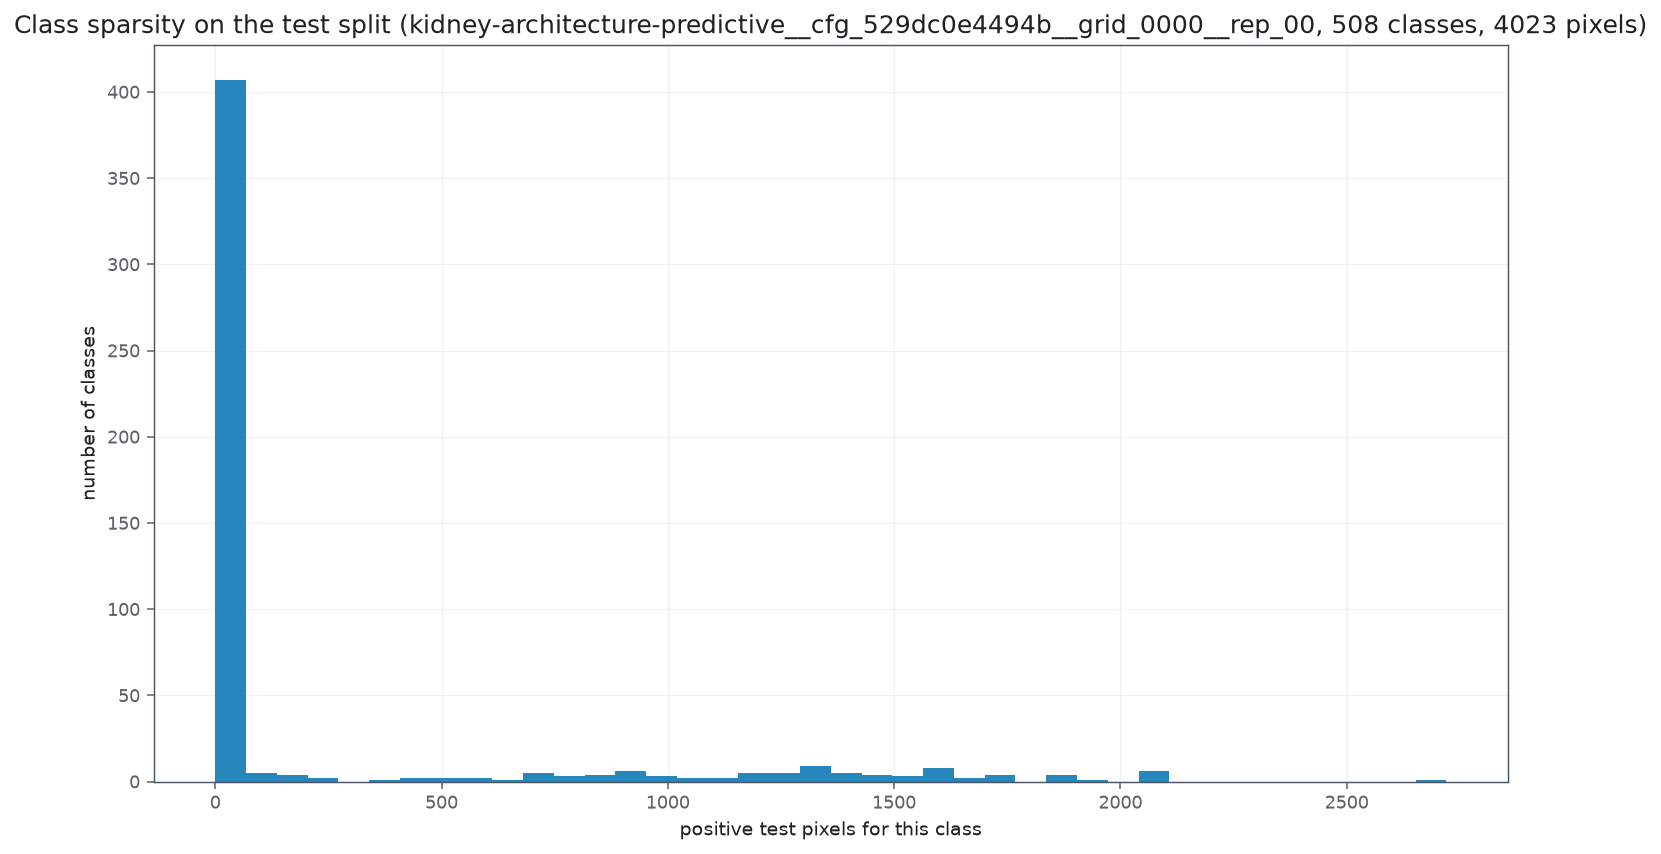

In [8]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
ax.hist(
    reference_class_metrics["positive_samples"],
    bins=40,
    color=theme.color_for_model("positive_samples", 0),
    alpha=theme.primary_alpha,
)
ax.set(
    xlabel="positive test pixels for this class",
    ylabel="number of classes",
    title=f"Class sparsity on the test split ({MODEL_NAMES[0]}, {class_count} classes, {reference_result['test_size']} pixels)",
)
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()


## The trap, made explicit: an all-zero predictor's metrics

Feeds a constant, strongly-negative logit (every predicted probability ≈ 0, so nothing
crosses the 0.5 threshold) through the exact same `evaluate_head` used for the trained
model — same metric functions, same test split, same mask. `hamming_loss` and
`micro_precision`/`micro_recall` collapse toward the always-negative class's dominance;
`average_precision` (macro AUPRC, one value per class then averaged) does not, since
each class's baseline is its own prevalence rather than the global (dominated-by-zero)
label balance — this is exactly why `average_precision` is the headline metric to trust
here, not accuracy-shaped ones.


In [9]:
def zero_baseline_logits(shape: tuple[int, int]) -> np.ndarray:
    return np.full(shape, -30.0, dtype=np.float32)  # sigmoid(-30) ~ 9e-14, avoids exp() overflow warning


baseline_rows = []
model_rows = []
for model_name, result in results.items():
    baseline_metrics = evaluate_head(
        zero_baseline_logits(result["logits"].shape), result["targets"], "multi_label", result["mask"], THRESHOLD
    )
    model_metrics = evaluate_head(
        result["logits"], result["targets"], "multi_label", result["mask"], THRESHOLD
    )
    baseline_rows.append({"model_name": model_name, **baseline_metrics})
    model_rows.append({"model_name": model_name, **model_metrics})

comparison = pd.concat(
    [
        pd.DataFrame(baseline_rows).assign(predictor="all-zero baseline"),
        pd.DataFrame(model_rows).assign(predictor="trained model"),
    ],
    ignore_index=True,
).set_index(["predictor", "model_name"])
comparison


micro_f1  \
predictor         model_name                                                     
all-zero baseline kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
trained model     kidney-architecture-predictive__cfg_529dc0e4494...  0.129376   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.115802   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.112518   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.124834   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.107734   

                                                                      macro_f1  \
predictor         model_name                                                     
all-zero baseline kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
trained model     kidney-architecture-predictive__cfg_529dc0e4494...  0.051750   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.047010   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.043477   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.052439   
                  kidney-architecture-predictive__cfg_529dc0e4494...  0.044366   

                                                                      micro_precision  \
predictor         model_name                                                            
all-zero baseline kidney-architecture-predictive__cfg_529dc0e4494...         0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.000000   
trained model     kidney-architecture-predictive__cfg_529dc0e4494...         0.076493   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.068702   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.066872   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.073760   
                  kidney-architecture-predictive__cfg_529dc0e4494...         0.063154   

                                                                      micro_recall  \
predictor         model_name                                                         
all-zero baseline kidney-architecture-predictive__cfg_529dc0e4494...      0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.000000   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.000000   
trained model     kidney-architecture-predictive__cfg_529dc0e4494...      0.419160   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.368288   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.354485   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.405886   
                  kidney-architecture-predictive__cfg_529dc0e4494...      0.366319   

In [10]:
comparison.groupby("predictor")[
    ["micro_f1", "macro_f1", "micro_precision", "micro_recall", "hamming_loss", "average_precision"]
].agg(["mean", "std"])


micro_f1            macro_f1          micro_precision  \
                       mean       std      mean      std            mean   
predictor                                                                  
all-zero baseline  0.000000  0.000000  0.000000  0.00000        0.000000   
trained model      0.118053  0.008894  0.047808  0.00413        0.069796   

                            micro_recall           hamming_loss            \
                        std         mean       std         mean       std   
predictor                                                                   
all-zero baseline  0.000000     0.000000  0.000000     0.057393  0.000000   
trained model      0.005349     0.382828  0.028013     0.328477  0.011244   

                  average_precision            
                               mean       std  
predictor                                      
all-zero baseline          0.258016  0.000000  
trained model              0.364260  0.016666

In [11]:
comparison.groupby("predictor")[
    ["micro_f1", "macro_f1", "micro_precision", "micro_recall", "hamming_loss", "average_precision"]
].agg(["mean", "std"])


micro_f1            macro_f1          micro_precision  \
                       mean       std      mean      std            mean   
predictor                                                                  
all-zero baseline  0.000000  0.000000  0.000000  0.00000        0.000000   
trained model      0.118053  0.008894  0.047808  0.00413        0.069796   

                            micro_recall           hamming_loss            \
                        std         mean       std         mean       std   
predictor                                                                   
all-zero baseline  0.000000     0.000000  0.000000     0.057393  0.000000   
trained model      0.005349     0.382828  0.028013     0.328477  0.011244   

                  average_precision            
                               mean       std  
predictor                                      
all-zero baseline          0.258016  0.000000  
trained model              0.364260  0.016666

## Per-class detail — worst and best classes by AUPRC (`grid_0000`, rep 0)

Classes with zero test positives are excluded here (`average_precision_score` is
undefined for a class with no positive examples in the evaluated set — sklearn returns
`nan`/raises a warning for it, not a meaningful zero); their count is already reported
above and they are, definitionally, pure false-positive risk for this model.


In [12]:
scored_classes = reference_class_metrics[reference_class_metrics["positive_samples"] > 0].copy()
scored_classes = scored_classes.sort_values("average_precision")
print(f"{len(scored_classes)}/{class_count} classes had ≥1 test positive and could be scored")

print("=== worst 10 by AUPRC ===")
display_cols = ["class_index", "positive_samples", "precision", "recall", "f1", "average_precision"]
scored_classes[display_cols].head(10)


113/508 classes had ≥1 test positive and could be scored
=== worst 10 by AUPRC ===


,class_index,positive_samples,precision,recall,f1,average_precision
179,179.0,2.0,0.000000,0.000000,0.000000,0.000452
283,283.0,10.0,0.000000,0.000000,0.000000,0.002028
304,304.0,24.0,0.003982,0.583333,0.007910,0.003658
89,89.0,35.0,0.000000,0.000000,0.000000,0.007795
305,305.0,12.0,0.000000,0.000000,0.000000,0.007822
169,169.0,9.0,0.005556,1.000000,0.011050,0.007856
485,485.0,3.0,0.000947,1.000000,0.001892,0.008064
139,139.0,89.0,0.019509,0.741573,0.038018,0.014550
264,264.0,87.0,0.000000,0.000000,0.000000,0.014685
141,141.0,56.0,0.000000,0.000000,0.000000,0.023316


In [13]:
print("=== best 10 by AUPRC ===")
scored_classes[display_cols].tail(10).sort_values("average_precision", ascending=False)


=== best 10 by AUPRC ===


,class_index,positive_samples,precision,recall,f1,average_precision
135,135.0,2099.0,1.000000,0.006193,0.012311,0.999912
142,142.0,1860.0,0.966396,0.896774,0.930284,0.975358
130,130.0,1958.0,1.000000,0.356997,0.526157,0.972579
214,214.0,1371.0,0.000000,0.000000,0.000000,0.971267
173,173.0,1427.0,0.000000,0.000000,0.000000,0.969450
288,288.0,927.0,0.647687,0.981661,0.780446,0.964802
124,124.0,1714.0,0.000000,0.000000,0.000000,0.955439
372,372.0,1292.0,0.000000,0.000000,0.000000,0.949943
149,149.0,1710.0,0.784672,0.880117,0.829658,0.948591
394,394.0,1484.0,0.000000,0.000000,0.000000,0.944013


## Repetition variance

Same `average_precision`/`macro_f1` summary as above, but per repetition, to see
whether `grid_0000`'s prediction quality is stable across the 5 shared-seed runs or
noisy enough that a single-repetition read (e.g. only rep 0 above) would be misleading.


In [14]:
comparison.loc["trained model"][["macro_f1", "average_precision", "hamming_loss"]]


,macro_f1,average_precision,hamming_loss
model_name,,,
kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00,0.051750,0.385860,0.323778
kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_01,0.047010,0.377192,0.322785
kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_02,0.043477,0.345492,0.320944
kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_03,0.052439,0.357008,0.326627
kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_04,0.044366,0.355747,0.348251


## Notes for the next pass

Facts established here, not yet interpreted:

- `average_precision` (macro AUPRC) is the metric to lead with for this head — it is
  the one in the comparison table above that actually separates the trained model from
  the all-zero baseline; the accuracy-shaped metrics (`hamming_loss`,
  `micro_precision`) do not, exactly as the introduction warned.
- A large fraction of the 508 classes have zero positive pixels on this particular
  4023-pixel test split (see the sparsity histogram) — those are excluded from the
  per-class AUPRC ranking above since the metric is undefined for them, not because
  they are unimportant; every predicted positive on one of them is definitionally a
  false positive for this evaluation.
- Not yet done: the same evaluation for the other six `objectives` ablations (this
  notebook only reused `grid_0000`'s `describe_objective` label as a filename
  suffix — extending `MODEL_NAMES` to another `grid_000N` and re-running reproduces
  this whole notebook for it), and per-class spatial maps (`../report/methodology.md`
  mentions counterfactual peak-ablation as a stronger causal test than these
  classification metrics alone — a later, separate analysis).
- The environment workaround above (`SCRATCH_WORKSPACE_ROOT` symlink) is local to this
  machine's `/tmp`; a fresh environment needs it recreated before this notebook (or any
  notebook loading a predictive-campaign model through `wrapper.load_configuration`)
  will run.
